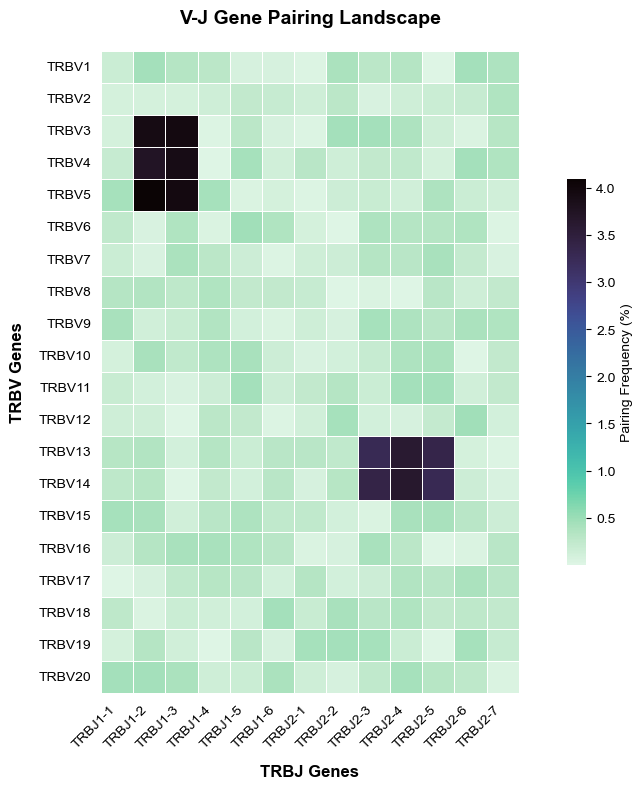

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 模拟 V-J 配对频率数据
np.random.seed(42)
v_genes = [f'TRBV{i}' for i in range(1, 21)]  # 20 个 V 基因
j_genes = [f'TRBJ{1}-{i}' for i in range(1, 7)] + [f'TRBJ{2}-{i}' for i in range(1, 8)] # 13 个 J 基因

data = np.random.rand(len(v_genes), len(j_genes)) * 0.5
# 模拟特定的 V-J 优势扩增 
data[2:5, 1:3] += 4.0   
data[12:14, 8:11] += 3.5 

df_vj = pd.DataFrame(data, index=v_genes, columns=j_genes)
df_vj = df_vj.div(df_vj.sum().sum()) * 100 

# 2. 绘制 SCI 级别热图
plt.rcParams['font.sans-serif'] = ['Arial']
fig, ax = plt.subplots(figsize=(10, 8)) 

sns.heatmap(
    df_vj, 
    cmap='mako_r', 
    square=True,          
    linewidths=0.5,       
    linecolor='white',    
    cbar_kws={
        "shrink": 0.6,    
        "label": "Pairing Frequency (%)", 
        "orientation": "vertical"
    },
    ax=ax
)

ax.set_xlabel("TRBJ Genes", fontweight='bold', fontsize=12, labelpad=10)
ax.set_ylabel("TRBV Genes", fontweight='bold', fontsize=12, labelpad=10)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.tick_params(left=False, bottom=False)

plt.title("V-J Gene Pairing Landscape", fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
#plt.savefig('VJ_Heatmap.pdf', dpi=300, bbox_inches='tight')
#print("热图已保存为 VJ_Heatmap.pdf")


In [1]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.colors as mcolors

# ==========================================
# 1. 生成顶刊级别的莫兰迪配色 (Morandi Palette)
# ==========================================
palette_muted = sns.color_palette("muted", 10).as_hex()
palette_pastel = sns.color_palette("pastel", 10).as_hex()
morandi_colors = [val for pair in zip(palette_muted, palette_pastel) for val in pair]

# 辅助函数：将 Hex 颜色转换为带有透明度的 rgba 格式，供丝带使用
def hex_to_rgba(hex_color, alpha=0.4):
    rgb = mcolors.hex2color(hex_color)
    return f"rgba({int(rgb[0]*255)}, {int(rgb[1]*255)}, {int(rgb[2]*255)}, {alpha})"

# ==========================================
# 2. 模拟 V-J 强相关配对数据
# ==========================================
np.random.seed(42)
v_genes = [f'TRBV{i}' for i in range(1, 11)] 
j_genes = [f'TRBJ{1}-{i}' for i in range(1, 6)] 

source_indices = []
target_indices = []
values = []

node_labels = v_genes + j_genes

for i, v in enumerate(v_genes):
    for j, j_g in enumerate(j_genes):
        freq = np.random.rand() * 2
        if (i < 3 and j < 2) or (i > 7 and j > 3):  
            freq += 15
        if freq > 1.5: 
            source_indices.append(i)
            target_indices.append(len(v_genes) + j)
            values.append(freq)

# ==========================================
# 3. 严格分配节点与连线的颜色
# ==========================================
node_colors = morandi_colors[:len(v_genes)] + ['#B0B0B0'] * len(j_genes)
link_colors = [hex_to_rgba(morandi_colors[src], 0.4) for src in source_indices]

# ==========================================
# 4. 绘制并渲染顶刊级桑基图
# ==========================================
fig = go.Figure(data=[go.Sankey(
    arrangement="perpendicular", 
    node=dict(
        pad=20,          
        thickness=15,    
        # 【修复】使用 rgba(0,0,0,0) 实现完全透明的边框
        line=dict(color="rgba(0,0,0,0)", width=0), 
        label=node_labels,
        color=node_colors
    ),
    link=dict(
        source=source_indices,
        target=target_indices,
        value=values,
        color=link_colors
    )
)])

fig.update_layout(
    title_text="V-J Pairing Flow", 
    font_size=12,
    font_family="Arial",
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=800,
    height=600,
    margin=dict(l=50, r=50, t=50, b=50) 
)

fig.write_image("VJ_pairing.png", scale=3)
#print("✅ 顶刊莫兰迪版桑基图已生成！请在浏览器中打开 VJ_Sankey_Morandi.html 查看。")

In [3]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import seaborn as sns

# 1. 模拟三层层级数据：Total -> V家族 -> 具体CDR3克隆
# 故意制造长尾分布：少数高频克隆，大量极低频克隆
np.random.seed(42)

data = {
    'V_Family': ['TRBV7']*10 + ['TRBV12']*10 + ['TRBV20']*10,
    'CDR3_Sequence': [f'CASS{i}YEQYF' for i in range(1, 11)] + 
                     [f'CASS{i}SGLNTG' for i in range(11, 21)] + 
                     [f'CASS{i}GGTNYG' for i in range(21, 31)],
    'Frequency': [15, 8, 5, 1, 0.5, 0.5, 0.2, 0.2, 0.2, 0.2] +  # TRBV7的克隆
                 [12, 6, 4, 1, 0.5, 0.5, 0.2, 0.2, 0.2, 0.2] +  # TRBV12的克隆
                 [20, 10, 3, 1, 0.5, 0.5, 0.2, 0.2, 0.2, 0.2]   # TRBV20的克隆
}
df_raw = pd.DataFrame(data)

# 【关键优化：数据降噪】
# 对每个V家族，保留Top 3克隆，其余合并为 "Others"
processed_rows = []
for v_fam, sub_df in df_raw.groupby('V_Family'):
    sub_df = sub_df.sort_values(by='Frequency', ascending=False)
    top_clones = sub_df.head(3)
    others_freq = sub_df.iloc[3:]['Frequency'].sum()
    
    processed_rows.append(top_clones)
    processed_rows.append(pd.DataFrame({
        'V_Family': [v_fam],
        'CDR3_Sequence': [f'{v_fam}_Others'], # 独立命名防止冲突
        'Frequency': [others_freq]
    }))

df_plot = pd.concat(processed_rows, ignore_index=True)

# 2. 构建 Plotly 旭日图所需的层级结构 (ids, labels, parents, values, colors)
ids = ['Total', 'TRBV7', 'TRBV12', 'TRBV20']
labels = ['Total Portfolio', 'TRBV7', 'TRBV12', 'TRBV20']
parents = ['', 'Total', 'Total', 'Total']
values = [df_plot['Frequency'].sum(), 
          df_plot[df_plot['V_Family']=='TRBV7']['Frequency'].sum(),
          df_plot[df_plot['V_Family']=='TRBV12']['Frequency'].sum(),
          df_plot[df_plot['V_Family']=='TRBV20']['Frequency'].sum()]

# 莫兰迪底色映射
color_map = {
    'Total': '#E5E5E5',
    'TRBV7': '#7FB3D5',   # 柔和蓝
    'TRBV12': '#F1948A',  # 柔和红
    'TRBV20': '#85C1E9'   # 柔和青
}
colors = [color_map['Total'], color_map['TRBV7'], color_map['TRBV12'], color_map['TRBV20']]

# 填入最外圈（CDR3克隆）
for _, row in df_plot.iterrows():
    ids.append(row['CDR3_Sequence'])
    # 如果是合并项，标签显示为简洁的 "Others"
    label_text = "Others" if "Others" in row['CDR3_Sequence'] else row['CDR3_Sequence']
    labels.append(label_text)
    parents.append(row['V_Family'])
    values.append(row['Frequency'])
    
    # 颜色继承父亲（V家族），但如果是Others则赋予中性浅灰色
    if "Others" in row['CDR3_Sequence']:
        colors.append('#D5D8DC')
    else:
        colors.append(color_map[row['V_Family']])

# 3. 绘制旭日图
fig = go.Figure(go.Sunburst(
    ids=ids,
    labels=labels,
    parents=parents,
    values=values,
    branchvalues="total",
    marker=dict(colors=colors, line=dict(color='white', width=1)), # 白色切割线带来呼吸感
    insidetextorientation='radial' # 文字沿着半径方向排列，规整不突兀
))

fig.update_layout(
    margin=dict(t=40, l=40, r=40, b=40),
    width=700,
    height=700,
    paper_bgcolor='white'
)

# 保存 HTML（可在浏览器中无损放大并右键保存为高清 PNG）
#fig.write_html("TCR_Sunburst_Optimized.html")
#print("✅ 策略1：优化版旭日图已成功保存为 TCR_Sunburst_Optimized.html")

✅ 策略3：序列相似性网络图已成功保存为 TCR_Sequence_Network.pdf


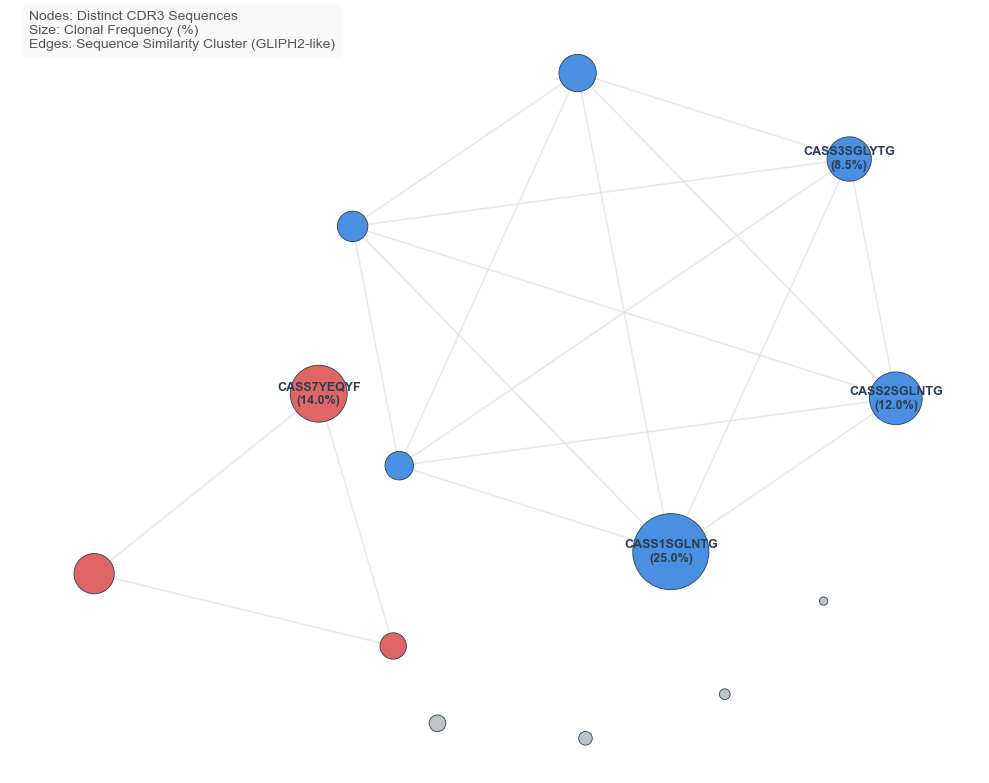

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# 1. 初始化无向图
G = nx.Graph()

# 2. 模拟具有强烈富集特征的 TCR 网络数据
# 模拟一个针对肿瘤核心抗原的超大特异性克隆簇 (Cluster A)
cluster_A = {
    'CASS1SGLNTG': 25.0, 'CASS2SGLNTG': 12.0, 'CASS3SGLYTG': 8.5, 
    'CASS4SGLSTG': 6.0,  'CASS5AGLNTG': 4.0,  'CASS6SGLNTG': 3.5
}
# 模拟一个次要的克隆簇 (Cluster B)
cluster_B = {
    'CASS7YEQYF': 14.0, 'CASS8YEQYF': 7.0, 'CASS9FEQYF': 3.0
}
# 模拟一些平平无奇、没有特异性富集的孤立单克隆 (Singletons)
singletons = {
    'CASSRANDOM1': 1.2, 'CASSRANDOM2': 0.8, 'CASSRANDOM3': 0.5, 'CASSRANDOM4': 0.3
}

# 合并所有节点到图中
all_nodes = {**cluster_A, **cluster_B, **singletons}
for node, freq in all_nodes.items():
    G.add_node(node, frequency=freq)

# 3. 建立连线（模拟生物学相似性：例如 CDR3 氨基酸序列仅相差1个错配，或共享识别Motif）
# Cluster A 内部高度连通
nodes_A = list(cluster_A.keys())
for i in range(len(nodes_A)):
    for j in range(i + 1, len(nodes_A)):
        G.add_edge(nodes_A[i], nodes_A[j], weight=1.5)

# Cluster B 内部连通
nodes_B = list(cluster_B.keys())
for i in range(len(nodes_B)):
    for j in range(i + 1, len(nodes_B)):
        G.add_edge(nodes_B[i], nodes_B[j], weight=1.0)

# 4. 绘图高级排版设置
plt.rcParams['font.sans-serif'] = ['Arial']
fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')

# 使用 Kamada-Kawai 力学布局算法，它能把有紧密配对关系的节点完美聚成“孤岛”
pos = nx.kamada_kawai_layout(G)

# 分离节点属性用于高级上色
node_sizes = [G.nodes[node]['frequency'] * 120 for node in G.nodes] # 面积映射频率

# 颜色映射：核心富集簇用高质感的莫兰迪蓝和红，孤立节点用低调的冷灰色
node_colors = []
for node in G.nodes:
    if node in cluster_A:
        node_colors.append('#4A90E2') # 莫兰迪科技蓝
    elif node in cluster_B:
        node_colors.append('#E06666') # 莫兰迪暗红
    else:
        node_colors.append('#BDC3C7') # 降噪灰

# 5. 绘制网络图元素
# 绘制连线：半透明细灰色线，绝不抢走节点的视觉焦点
nx.draw_networkx_edges(G, pos, width=1.2, edge_color='#E0E0E0', alpha=0.7, ax=ax)

# 绘制节点：带上细黑边，增加呼吸感与立体质感
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, 
                       edgecolors='#2C3E50', linewidths=0.6, ax=ax)

# 6. 精准标签标注（顶刊规范：只标注核心优势克隆，绝不让文字密密麻麻叠加）
labels = {}
for node in G.nodes:
    # 只为频率大于 8% 的核心克隆打上标签
    if G.nodes[node]['frequency'] >= 8.0:
        labels[node] = f"{node}\n({G.nodes[node]['frequency']}%)"

# 让标签悬浮在节点上方，避免文字被圆点遮挡
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_family='Arial',
                        font_weight='bold', font_color='#2C3E50')

# 7. 极简主义美化
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

# 添加图注（科研严谨性）
ax.text(0.02, 0.95, "Nodes: Distinct CDR3 Sequences\nSize: Clonal Frequency (%)\nEdges: Sequence Similarity Cluster (GLIPH2-like)", 
        transform=ax.transAxes, fontsize=10, color='#555555', bbox=dict(facecolor='#F9F9F9', edgecolor='none', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.savefig('TCR_Sequence_Network.pdf', dpi=300, bbox_inches='tight')
print("✅ 策略3：序列相似性网络图已成功保存为 TCR_Sequence_Network.pdf")

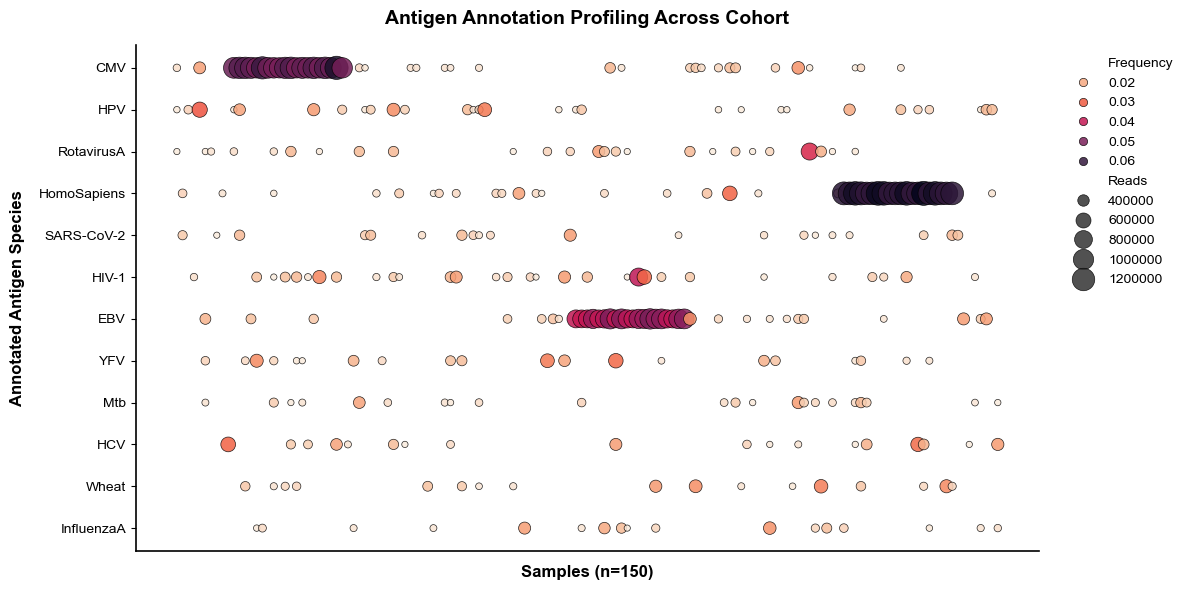

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. 模拟您的真实高密度数据 (15个抗原, 150个样本)
# ---------------------------------------------------------
np.random.seed(42)
antigens = ['SARS-CoV-2', 'CMV', 'EBV', 'HIV-1', 'InfluenzaA', 'HomoSapiens', 
            'Mtb', 'HPV', 'HCV', 'RotavirusA', 'Wheat', 'YFV']
n_samples = 150
samples = [f'S{i}' for i in range(n_samples)]

# 模拟大部分是极低噪音，少数是高频信号
data_freq = np.random.exponential(scale=0.005, size=(len(antigens), n_samples))
data_reads = data_freq * 20000000  # 模拟 Reads

# 制造特异性强信号：让一部分样本在 CMV, EBV, HomoSapiens 上极高
data_freq[1, 10:30] += 0.05   # CMV
data_freq[2, 70:90] += 0.04   # EBV
data_freq[5, 120:140] += 0.06 # HomoSapiens

# ---------------------------------------------------------
# 2. 数据清洗与重构 (顶刊排版的核心)
# ---------------------------------------------------------
df = pd.DataFrame(data_freq, index=antigens, columns=samples)

# [核心优化1]：对 Y 轴抗原按整体丰度排序，把高频的放上面
antigen_order = df.sum(axis=1).sort_values(ascending=False).index
df = df.loc[antigen_order]

# [核心优化2]：将宽表转换为长表，并应用“去噪阈值”
df_long = df.reset_index().melt(id_vars='index', var_name='Sample', value_name='Frequency')
df_long.rename(columns={'index': 'Antigen'}, inplace=True)

# 强制过滤掉低于 0.01 的噪音背景！(这一步拯救了整张图)
df_clean = df_long[df_long['Frequency'] >= 0.01].copy()

# 为了模拟气泡大小，我们将 Frequency 同步映射给一个 Count 值
df_clean['Reads'] = df_clean['Frequency'] * 20000000

# ---------------------------------------------------------
# 3. 绘制高级稀疏气泡图
# ---------------------------------------------------------
plt.rcParams['font.sans-serif'] = ['Arial']
fig, ax = plt.subplots(figsize=(12, 6)) # 采用宽屏比例适应众多样本

# 使用 Seaborn 绘制气泡，选用 rocket_r (深紫到亮红)，剔除蓝色噪音
scatter = sns.scatterplot(
    data=df_clean,
    x='Sample',
    y='Antigen',
    size='Reads',
    hue='Frequency',
    palette='rocket_r',  # 顶刊爱用的暖色系渐变
    sizes=(20, 300),     # 控制气泡大小范围
    alpha=0.85,
    edgecolor='black',   # 给气泡加细黑边，提升质感
    linewidth=0.5,
    ax=ax
)

# ---------------------------------------------------------
# 4. 彻底解决排版灾难
# ---------------------------------------------------------
# 隐藏密密麻麻的 X 轴样本名
ax.set_xticks([])
ax.set_xlabel("Samples (n=150)", fontweight='bold', fontsize=12, labelpad=10)
ax.set_ylabel("Annotated Antigen Species", fontweight='bold', fontsize=12, labelpad=10)

# 极简坐标轴边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_linewidth(1.2)

# 将图例移到图表外部右侧，防止遮挡数据
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.title("Antigen Annotation Profiling Across Cohort", fontweight='bold', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('Optimized_Antigen_Bubble.pdf', dpi=300, bbox_inches='tight')